## [Персональные рекомендации|Avito ML cup 2025](https://ods.ai/competitions/avitotechmlchallenge2025)

In [13]:
from lab2.src.cache.cache import Cache
from lab2.src.data.data_matrix.data_matrix import DataMatrix
from lab2.src.data.process.data_process_func import process_all_data
from lab2.src.eda.eda import Eda
from lab2.src.eda.eda_plot_funcs import show_eda_plots
from lab2.src.data.load.data_installer import DataInstaller
from lab2.src.feature.feature_generator_func import generate_features
from lab2.src.recomendation.recomendation_func import fit
from lab2.src.recomendation.scoring.plot_func import show_scoring_plot
from lab2.src.recomendation.scoring.scoring_func import evaluation_with_fixes, show_scoring_results
from lab2.src.results import show_results

cache = Cache()

# 1) Выбрать датасет, подходящий для моделирования рекомендательной системы.

In [3]:
data_installer = DataInstaller()
data_installer.show_samples()

ДАННЫЕ
Text features: (22646691, 2)
Category features: (22646691, 5)
Clickstream: (68806152, 7)
Events: (19, 2)
Test users: (92319, 1)

Первые 5 строк каждого датасета:

Text Features:
   item                                   title_projection
0     9  [-128, 90, 127, -68, -12, -128, -9, 89, -45, 4...
1    17  [-128, 127, -128, -20, -128, -128, -128, -128,...
2   144  [-128, 97, 127, 127, -128, -128, 15, 127, 107,...
3   202  [-128, 127, 127, -72, 10, -86, -45, -128, 127,...
4   236  [-128, 29, 127, 74, 43, -49, 115, -54, 127, 94...

Category Features:
   item  location  category  \
0     9    8385.0      57.0   
1    17    2707.0      35.0   
2   144    8383.0       8.0   
3   202    5397.0      57.0   
4   236    2105.0      64.0   

                                        clean_params    node  
0  [{"attr":1157,"value":664427},{"attr":4682,"va...  194747  
1  [{"attr":2140,"value":501466},{"attr":1897,"va...  352905  
2  [{"attr":802,"value":35791},{"attr":4353,"valu...   17188  
3 

# 2) Сделать разведочный анализ данных (EDA)

In [4]:
eda = Eda(
    data_installer.text_features,
    data_installer.cat_features,
    data_installer.clickstream,
    data_installer.events,
    data_installer.test_users,
    cache,
)

eda.show()

EDA

1. АНАЛИЗ ТЕКСТОВЫХ ФИЧ:
Уникальные объявления: 22646691
Размерность векторов: 64
Пропуски: 0

2. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ФИЧ:
Уникальные локации: 4822
Уникальные категории: 52
Уникальные ноды: 408474
Пропуски: item            0
location        1
category        1
clean_params    0
node            0
dtype: int64

3. АНАЛИЗ CLEAN_PARAMS:
Среднее количество параметров: 9.54
Максимальное количество параметров: 38

4. АНАЛИЗ СОБЫТИЙ:
Распределение типов событий:
event
0     1
2     1
17    1
14    1
10    1
13    1
9     1
1     1
6     1
8     1
11    1
5     1
18    1
12    1
3     1
15    1
16    1
4     1
19    1
Name: count, dtype: int64

Контактные события:
is_contact
1    13
0     6
Name: count, dtype: int64

5. АНАЛИЗ КЛИКСТРИМА:
Период данных: 2025-01-10 00:00:00 - 2025-02-23 00:00:00
Уникальные пользователи: 134294
Уникальные объявления: 22646691
Уникальные события: 19

Распределение платформ:
platform
2    40252188
3    24307843
0     2253252
5     1980699
1       10299
4    

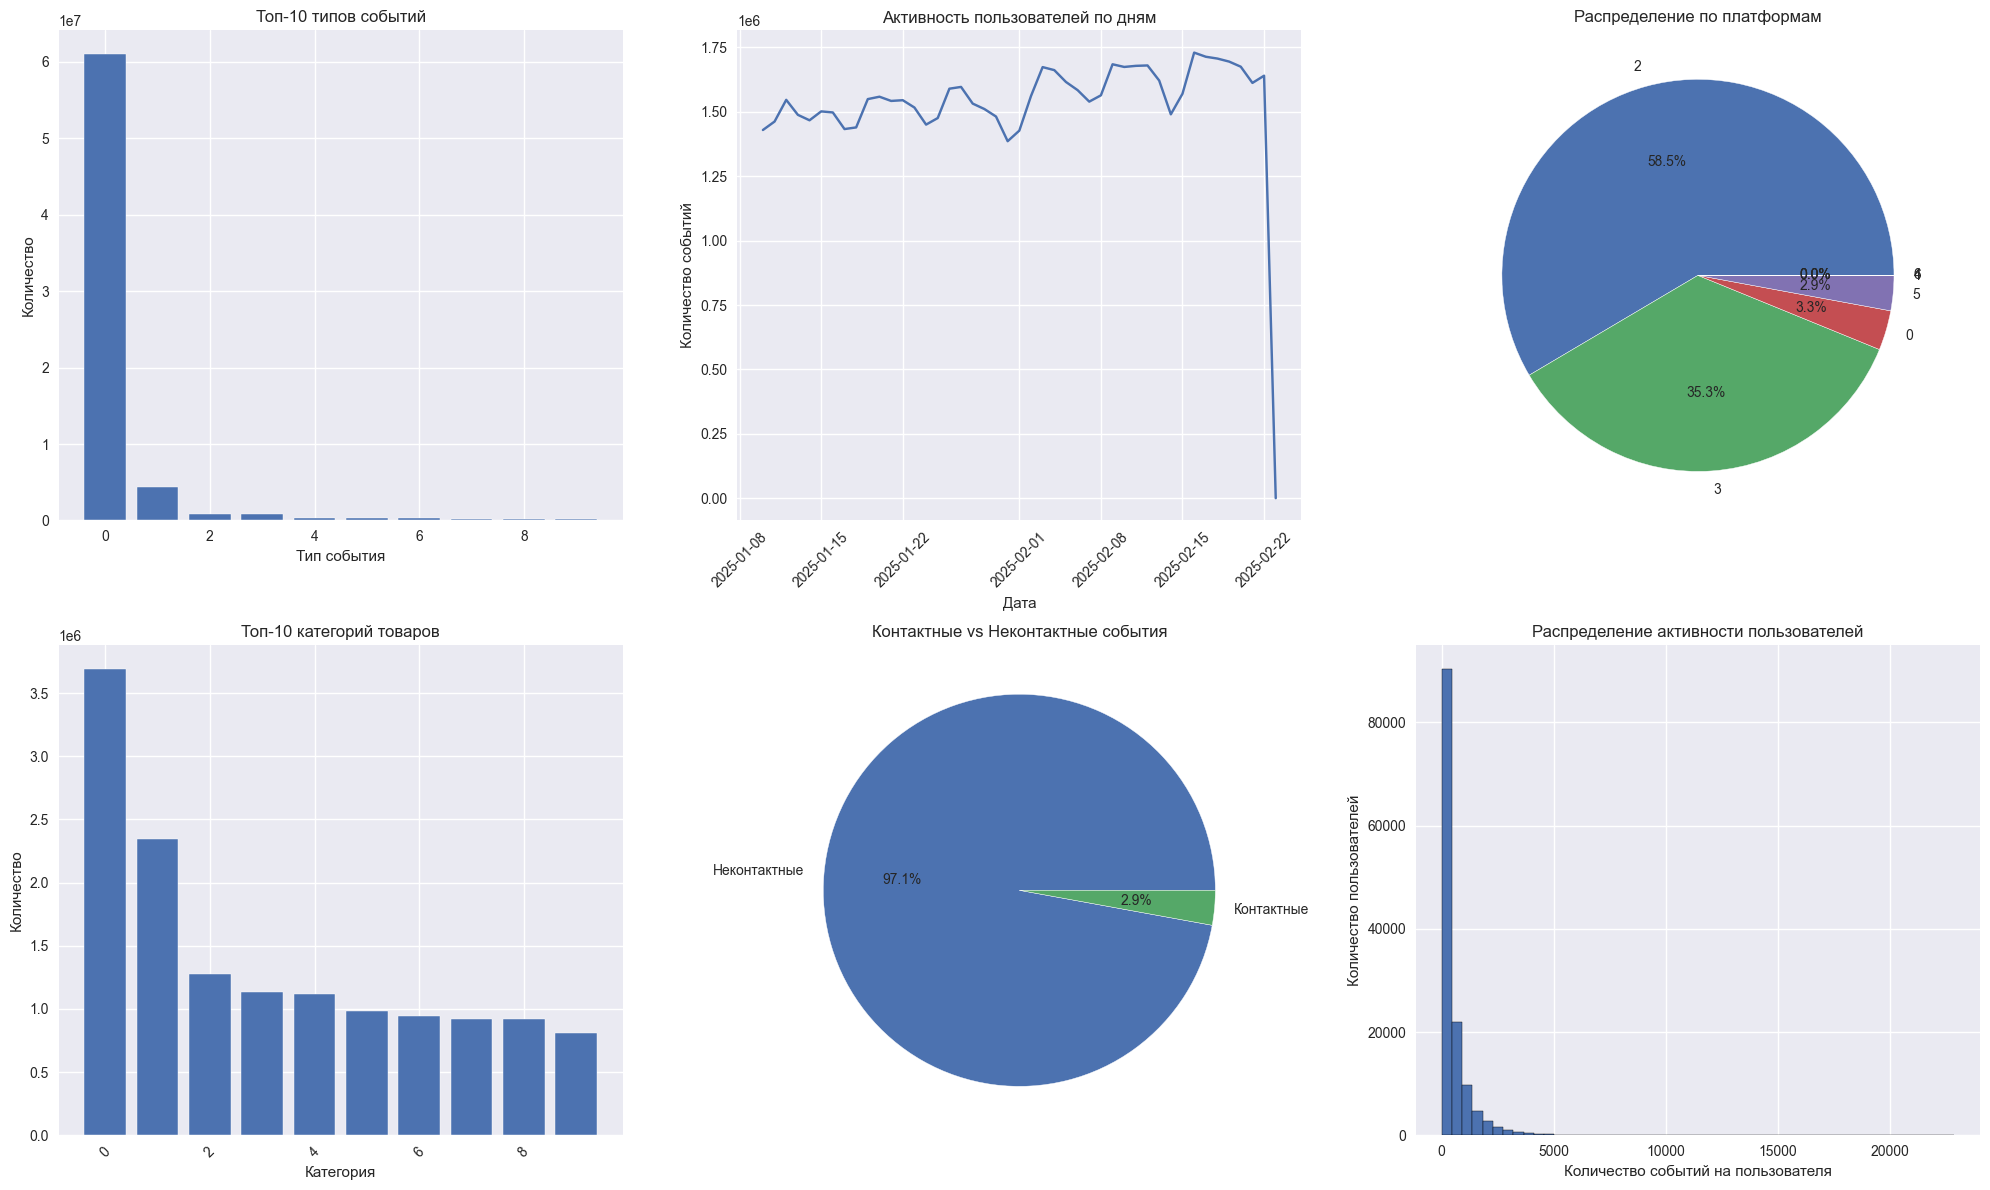


6. СТАТИСТИКИ АКТИВНОСТИ ПОЛЬЗОВАТЕЛЕЙ:
Среднее событий на пользователя: 512.35
Медиана событий на пользователя: 231.00
Максимум событий на пользователя: 22864


In [5]:
show_eda_plots(eda)

# 3) Выбрать минимум три метода формирования рекомендации.

In [6]:
clickstream_processed, text_features_processed, cat_features_processed = process_all_data(eda, cache)

print(f"После оптимизированной фильтрации: {clickstream_processed.shape[0]} взаимодействий")
print(f"Активных пользователей: {clickstream_processed['cookie'].nunique()}")

После фильтрации: 68804696 взаимодействий
Активных пользователей: 132838
После оптимизированной фильтрации: 68804696 взаимодействий
Активных пользователей: 132838


In [7]:
user_features, item_features = generate_features(
    clickstream_processed,
    cat_features_processed,
    text_features_processed,
)

Генерация фич пользователей...
Генерация фич объявлений...


In [8]:
train_matrix, test_matrix, common_users = DataMatrix.get_matrix(
    clickstream_processed,
)

Исходное разделение:
  Train: 57031010 взаимодействий, 129429 пользователей
  Test: 11773686 взаимодействий, 114939 пользователей
Ограниченный train:
  Пользователей: 4812
  Товаров: 9814
  Взаимодействий: 311130
Отфильтрованный test:
  Пользователей: 3459
  Товаров: 4598
  Взаимодействий: 25467
Итоговые матрицы:
  Train: (3435, 4591)
  Test: (3435, 4591)
  Общие пользователи: 3435
  Общие товары: 4591


In [9]:
recommender = fit(train_matrix)

Обучение Most Popular...
Most Popular: 4000 рекомендаций
Примеры: [24215356, 22276054, 25385907]
Обучение ItemKNN...
Вычисление схожести для 4591 товаров...
Обучение ALS...


100%|██████████| 15/15 [01:30<00:00,  6.01s/it]

ALS модель успешно обучена


# 4) Выбрать не менее трёх метрик оценки качества рекомендаций.

In [10]:
evaluation_results = evaluation_with_fixes(recommender, test_matrix, train_matrix)
show_scoring_results(recommender, test_matrix, train_matrix)

оценка на 50 пользователях
Оценка most_popular...
  Успешных пользователей: 50/50
Оценка item_knn...
  Успешных пользователей: 50/50
Оценка als...
  Успешных пользователей: 50/50
оценка на 50 пользователях
Оценка most_popular...
  Успешных пользователей: 50/50
Оценка item_knn...
  Успешных пользователей: 50/50
Оценка als...
  Успешных пользователей: 50/50

MOST_POPULAR:
  precision@k: 0.0014
  recall@k: 0.3009
  ndcg@k: 0.0533
  coverage: 0.8713
  novelty: 0.0274
  successful_users: 50

ITEM_KNN:
  precision@k: 0.0026
  recall@k: 0.6050
  ndcg@k: 0.1608
  coverage: 0.9906
  novelty: 0.0318
  successful_users: 50

ALS:
  precision@k: 0.0014
  recall@k: 0.3824
  ndcg@k: 0.1021
  coverage: 1.0000
  novelty: 0.0300
  successful_users: 50


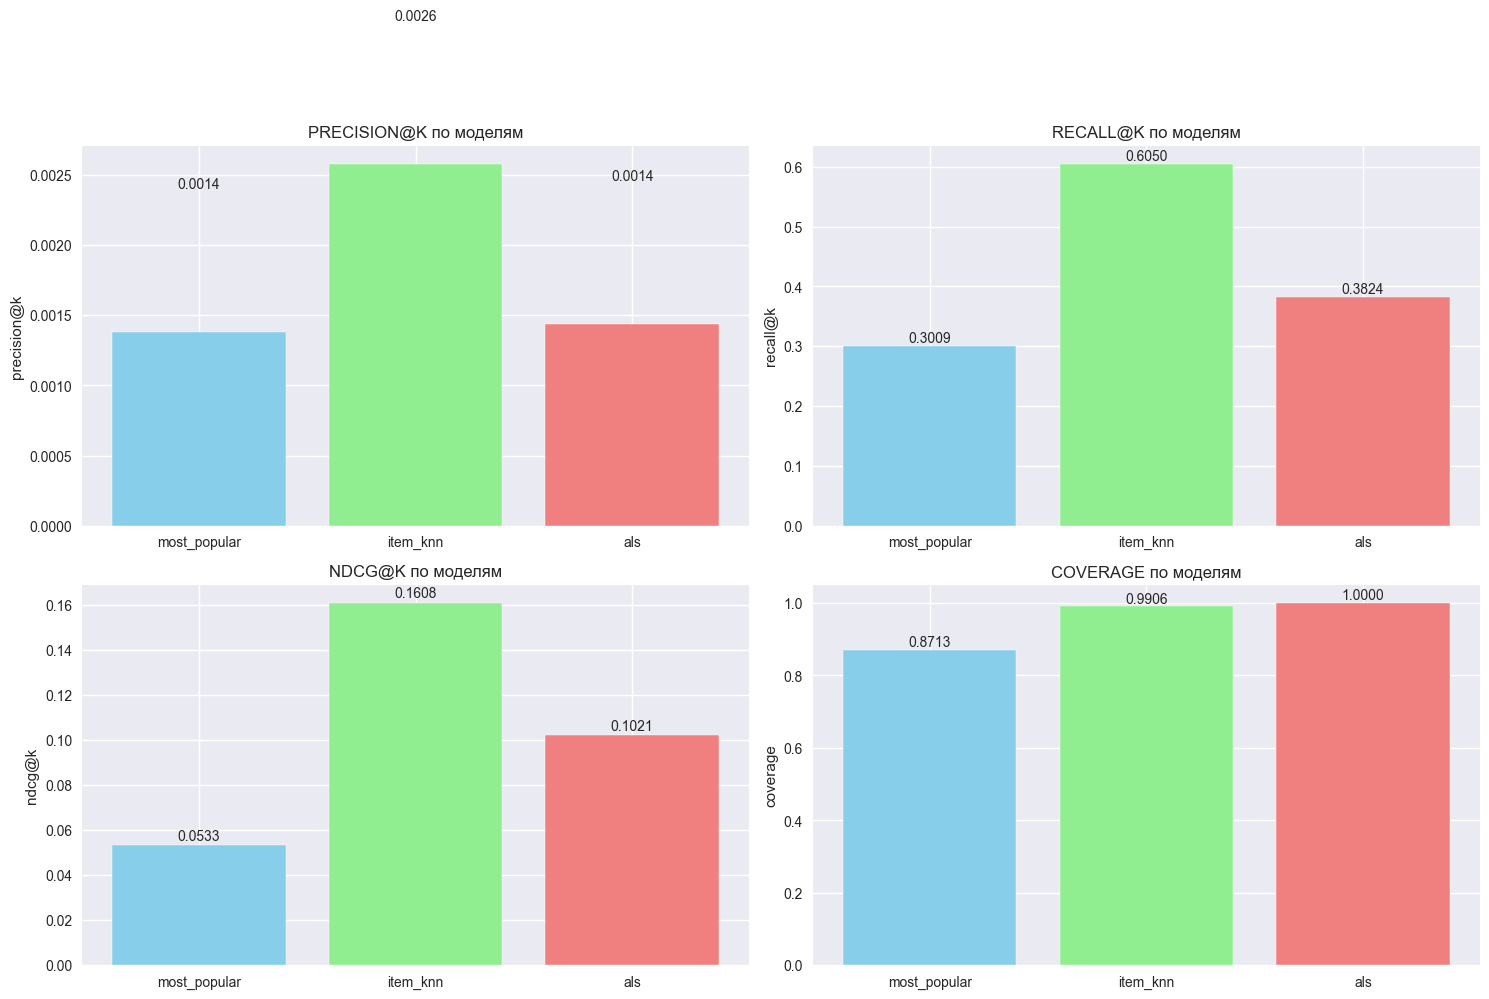


Сравнительная таблица моделей:
              precision@k  recall@k  ndcg@k  coverage  novelty  \
most_popular       0.0014    0.3009  0.0533    0.8713   0.0274   
item_knn           0.0026    0.6050  0.1608    0.9906   0.0318   
als                0.0014    0.3824  0.1021    1.0000   0.0300   

              successful_users  
most_popular              50.0  
item_knn                  50.0  
als                       50.0  


In [11]:
show_scoring_plot(evaluation_results)

In [12]:
show_results(eda.test_users, train_matrix, evaluation_results, recommender)

Колонки test_users: ['cookie']
Список тестовых пользователей: [ 52564 105000  57152  87303  37755 129902  65542  66590 111026 143535]

 Лучшая модель для финальных рекомендаций: item_knn

################################################################################
ФОРМИРОВАНИЕ РЕКОМЕНДАЦИЙ ДЛЯ МОДЕЛИ: ITEM_KNN
################################################################################
Генерация рекомендаций методом: item_knn
Количество тестовых пользователей: 92319
Успешно сгенерировано рекомендаций: 89940/92319

 ЛУЧШАЯ МОДЕЛЬ

МОДЕЛЬ: ITEM_KNN
Пользователь 52564:
    1. Товар: 24215356
    2. Товар: 22276054
    3. Товар: 25385907
    4. Товар: 1824964
    5. Товар: 6238550
    6. Товар: 10296307
    7. Товар: 15027858
    8. Товар: 25184762
    9. Товар: 27134640
   10. Товар: 7525856
Пользователь 105000:
    1. Товар: 24215356
    2. Товар: 22276054
    3. Товар: 25385907
    4. Товар: 1824964
    5. Товар: 6238550
    6. Товар: 10296307
    7. Товар: 15027858
    8. Товар

# 5) Сформулировать предложения по улучшению качества рекомендаций.

# Предложения по улучшению качества рекомендаций и выводы

## Анализ текущих результатов

- **ItemKNN** показала наилучшие результаты среди трех тестируемых моделей
- **ALS** генерирует значительно меньше рекомендаций на пользователя (77.3 vs 4000)
- Охват уникальных товаров у ALS выше (4591 vs 4000)

## Предложения по улучшению качества рекомендаций

### 1. Улучшение предобработки данных
- **Обогащение данных**: добавление демографической информации о пользователях
- **Взвешивание взаимодействий**: учет временных меток, частоты взаимодействий, длительности сессий
- **Фильтрация шума**: удаление нерелевантных или случайных взаимодействий

### 2. Усовершенствование моделей
- **Гибридные подходы**: комбинация ItemKNN с другими методами

### 3. Оптимизация гиперпараметров
- Для **ItemKNN**: подбор оптимального количества соседей, метрики схожести
- Для **ALS**: настройка количества факторов, регуляризации, количества эпох
- Систематический поиск по сетке для всех моделей

### 4. Персонализация
- **Сегментация пользователей**: разделение на группы по поведенческим паттернам

## Вывод

1. **ItemKNN** демонстрирует стабильную работу и является надежным базовым подходом
2. **ALS** требует дополнительной настройки для увеличения охвата рекомендаций
3. **Объединить подходы** - использовать ItemKNN как основу, но добавлять популярные товары, если не хватает рекомендаций